In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

'At first, I hadn\'t read the novel so far and I hadn\'t hear anything about the author yet. But as I casually saw this movie, I was totally captive by the story. Already as the Jewish watchman primary said, that he knows no one, who have a bad conscience about the war except from Howard W. Campbell Junior, was such amazing objective and dissociates from simply moralizing the war. Terrific! And the fictitious story about "the most effective spy for the USA in WWII", who have lost everything, that was important for his life, is wonderful emotional transcribed. This is the best story about the duality of humanity, I\'ve ever heard about! The questions, this movie is introducing, are in my opinion very important for our society: When does someone bear the guilt of something? What is guilt? Who is a hero and who is a felon? What is important in our life? Can you live without paying attention to the political changes? Is the protagonist guilty or not? These questions are more up to date tha

In [5]:
print(preprocess(df.iloc[random_num]['review']))

first read novel far hear anything author yet casually saw movie totally captive story already jewish watchman primary said know one bad conscience war except howard campbell junior amazing objective dissociates simply moralizing war terrific fictitious story effective spy usa wwii lost everything important life wonderful emotional transcribed best story duality humanity ever heard question movie introducing opinion important society someone bear guilt something guilt hero felon important life live without paying attention political change protagonist guilty question date last year must see everyone think acception war movie must see everyone meditate matter life


In [6]:
df['review'] = df['review'].apply(preprocess)

In [7]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [8]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [10]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [12]:
max_len = 5

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [36]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(2, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(4, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 5, 4)           │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 5, 4)           │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 2)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,073 (312.79 KB)

 Trainable params: 80,073 (312.79 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [38]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5153 - loss: 0.6919 - val_accuracy: 0.5993 - val_loss: 0.6882 - learning_rate: 5.0000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5417 - loss: 0.6846 - val_accuracy: 0.6616 - val_loss: 0.6706 - learning_rate: 5.0000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5637 - loss: 0.6680 - val_accuracy: 0.6834 - val_loss: 0.6398 - learning_rate: 5.0000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5847 - loss: 0.6527 - val_accuracy: 0.6925 - val_loss: 0.6183 - learning_rate: 5.0000e-04
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6057 - loss: 0.6364 - val_accuracy: 0.6964 - val_loss: 0.6035 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6303 - loss: 0.6219 - val_accuracy: 0.6996 - val_loss: 0.5905 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc

In [39]:
lstm_model.save_weights("lstm_modelo_leve.weights.h5")

In [40]:

lstm_model.load_weights("lstm_modelo_leve.weights.h5")

In [41]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [42]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7053 - loss: 0.5666
Test Accuracy: 0.705299973487854


#### Acurácia de 0.80119

# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


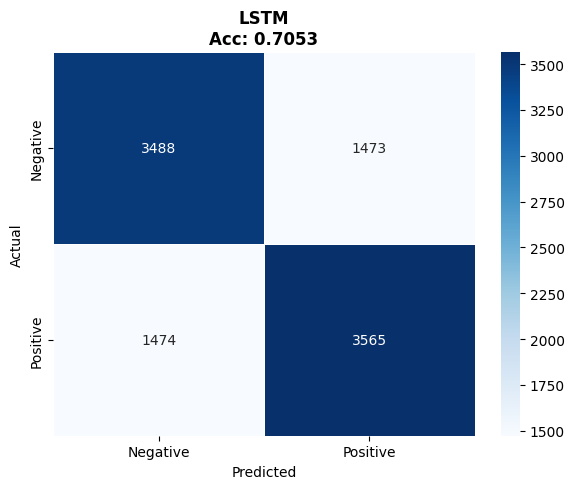

In [43]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [44]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.70      0.70      0.70      4961
    Positive       0.71      0.71      0.71      5039

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



# Teste de Outputs


In [45]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[0].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplest_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
Outputs salvos em layer_outputs_simplest_model.txt


# Exportação de Pesos

In [46]:
export_weights(lstm_model, mode='lstm', output_file="../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/weights.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_input[0][0] = 0.347601
  addr=0x08001 Wx_input[0][1] = -0.134445
  addr=0x08080 Wx_input[1][0] = -0.665431
  addr=0x08081 Wx_input[1][1] = -0.079056
  addr=0x08040 Wh_input[0][0] = -0.311534
  addr=0x08041 Wh_input[0][1] = 0.225871
  addr=0x080C0 Wh_input[1][0] = 0.472552
  addr=0x080C1 Wh_input[1][1] = 1.154557
  addr=0x18000 bias_input[0] = 0.770718
  addr=0x18080 bias_input[1] = 0.585654
  addr=0x0A000 Wx_forget[0][0] = 0.722272
  addr=0x0A001 Wx_forget[0][1] = 0.017135
  addr=0x0A080 Wx_forget[1][0] = 0.535469
  addr=0x0A081 Wx_forget[1][1] = -0.274108
  addr=0x0A040 Wh_forget[0][0] = 0.405960
  addr=0x0A041 Wh_forget[0][1] = -0.091147
  addr=0x0A0C0 Wh_forget[1][0] = -0.298279
  addr=0x0A0C1 Wh_forget[1][1] = 0.507669
  addr=0x1A000 bias_forget[0] = 1.187081
  addr=0x1A080 bias_forget[1] = 1.328802
  addr=0x0C000 Wx_candidate[0][0] = -1.170372
  addr=0x0

# Teste Global

In [47]:
FRAC = 24
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q24(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [48]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q24 = float_to_q24(valor)  # sua função original
            mem[addr] = valor_q24
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q24(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [49]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
#total = len(y_pred_lstm)
total = 10

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_{i}.mem")

    print(f"{i} de {total}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_0.mem
0 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_1.mem
1 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_2.mem
2 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_3.mem
3 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_4.mem
4 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_5.mem
5 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s